In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
dos_sample = (dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
dos_sample["label"] = "DoS_ATTACK"
dos_sample["label"].value_counts()
non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
non_dos_sample = (non_dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
non_dos_sample["label"] = "NON_DoS_ATTACK"
non_dos_sample["label"].value_counts()
attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
attack_sample["label"].value_counts()
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=non_dos_sample.shape[0], replace=False, random_state=42)
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [3]:
size = df_sample.shape[0]
df_sample.shape

(150000, 90)

In [4]:
df_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [5]:
filename = "clean_sample_" + str(size) + ".csv"
df_sample.to_csv(filename, index=False)

In [6]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)

In [10]:
input_size = 88
hidden_size = 128
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [11]:
model = MultiClassDNN().to()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [12]:
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(), y_batch.to()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(), y_batch.to()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.6083, Val Loss: 0.3908
Epoch 2, Train Loss: 0.3810, Val Loss: 0.3701
Epoch 3, Train Loss: 0.3716, Val Loss: 0.3671
Epoch 4, Train Loss: 0.3677, Val Loss: 0.3648
Epoch 5, Train Loss: 0.3665, Val Loss: 0.3629
Epoch 6, Train Loss: 0.3648, Val Loss: 0.3617
Epoch 7, Train Loss: 0.3640, Val Loss: 0.3621
Epoch 8, Train Loss: 0.3629, Val Loss: 0.3604
Epoch 9, Train Loss: 0.3611, Val Loss: 0.3609
Epoch 10, Train Loss: 0.3609, Val Loss: 0.3597
Epoch 11, Train Loss: 0.3602, Val Loss: 0.3586
Epoch 12, Train Loss: 0.3599, Val Loss: 0.3585
Epoch 13, Train Loss: 0.3590, Val Loss: 0.3586
Epoch 14, Train Loss: 0.3588, Val Loss: 0.3575
Epoch 15, Train Loss: 0.3587, Val Loss: 0.3578
Epoch 16, Train Loss: 0.3587, Val Loss: 0.3575
Epoch 17, Train Loss: 0.3577, Val Loss: 0.3572
Epoch 18, Train Loss: 0.3576, Val Loss: 0.3570
Epoch 19, Train Loss: 0.3574, Val Loss: 0.3571
Epoch 20, Train Loss: 0.3569, Val Loss: 0.3567
Epoch 21, Train Loss: 0.3567, Val Loss: 0.3566
Epoch 22, Train Loss: 

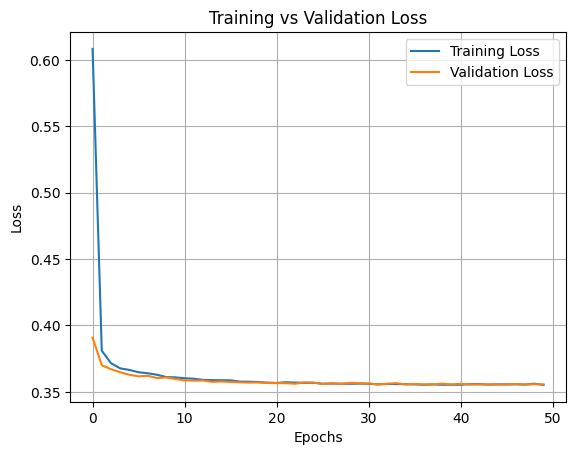

In [13]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [14]:
model.eval()
X_tensor = X_val_tensor.to()
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

In [15]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8902444444444444
Weighted F1: 0.8901885142067589
Macro F1: 0.890188514206759
ROC-AUC: 0.9700210499999999


In [16]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     15000
    DoS_ATTACK       0.83      0.85      0.84     15000
NON_DoS_ATTACK       0.84      0.82      0.83     15000

      accuracy                           0.89     45000
     macro avg       0.89      0.89      0.89     45000
  weighted avg       0.89      0.89      0.89     45000



In [17]:
def pgd_noise(model, X, y, epsilon, alpha=0.001, num_steps=100, random_start=True):
    model.eval()
    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.long)
    x_min = X.min()
    x_max = X.max()
    if random_start:
        delta = torch.empty_like(X).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(X)
    delta = delta.to()
    for _ in range(num_steps):
        delta.requires_grad_(True)
        X_adv = torch.clamp(X + delta, x_min, x_max)
        outputs = model(X_adv)
        loss = F.cross_entropy(outputs, y)
        model.zero_grad(set_to_none=True)
        if delta.grad is not None:
            delta.grad.zero_()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * torch.sign(grad)
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(X + delta, x_min, x_max) - X
        delta = delta.detach()
    X_adv = torch.clamp(X + delta, x_min, x_max)
    return X_adv.detach().cpu().numpy()

In [21]:
def epsilon_eval(epsilon):
    X_train_adv = pgd_noise(model, X_train, y_train, epsilon)
    X_val_adv   = pgd_noise(model, X_val, y_val, epsilon)
    model.eval()
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to()
    with torch.no_grad():
        clean_outputs = model(X_val_tensor)
        y_pred_clean = torch.argmax(clean_outputs, dim=1).cpu().numpy()
    X_adv_tensor = torch.tensor(X_val_adv, dtype=torch.float32).to()
    with torch.no_grad():
        adv_outputs = model(X_adv_tensor)
        y_pred = torch.argmax(adv_outputs, dim=1).cpu().numpy()
    y_true = y_val_tensor.cpu().numpy()
    correct_clean     = (y_pred_clean == y_true)
    x_adv_np = X_adv_tensor.cpu().numpy()
    adv_df = pd.DataFrame(scaler.inverse_transform(x_adv_np), columns=X.columns).round(0).astype(int)
    adv_df["true_label"] = y_true
    adv_df["y_pred"] = y_pred_clean
    filename = "noise_epsilon_" + str(epsilon) + ".csv"
    adv_df.to_csv(filename, index=False)
    successful_attacks = (correct_clean & (y_pred != y_true))
    asr = successful_attacks.sum() / max(correct_clean.sum(), 1)
    x_adv_np = X_val_adv if isinstance(X_val_adv, np.ndarray) else X_val_adv.cpu().numpy()
    clean_acc = accuracy_score(y_true, y_pred_clean)
    adv_acc   = accuracy_score(y_true, y_pred)
    print("=== ADVERSARIAL DATA ===")
    print("Epsilon:", epsilon)
    print("Accuracy:", adv_acc)
    print(classification_report(y_true, y_pred))
    return {"epsilon":epsilon, "clean_accuracy": clean_acc,"adv_accuracy":adv_acc, "asr":asr}

In [22]:
results = []
for epsilon in [0.01, 0.05, 0.1, 0.5]:
    results.append(epsilon_eval(epsilon))

=== ADVERSARIAL DATA ===
Epsilon: 0.01
Accuracy: 0.8889333333333334
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15000
           1       0.83      0.85      0.84     15000
           2       0.84      0.82      0.83     15000

    accuracy                           0.89     45000
   macro avg       0.89      0.89      0.89     45000
weighted avg       0.89      0.89      0.89     45000

=== ADVERSARIAL DATA ===
Epsilon: 0.05
Accuracy: 0.8442222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15000
           1       0.73      0.84      0.78     15000
           2       0.81      0.70      0.75     15000

    accuracy                           0.84     45000
   macro avg       0.85      0.84      0.84     45000
weighted avg       0.85      0.84      0.84     45000

=== ADVERSARIAL DATA ===
Epsilon: 0.1
Accuracy: 0.8245777777777777
              precision    recall  

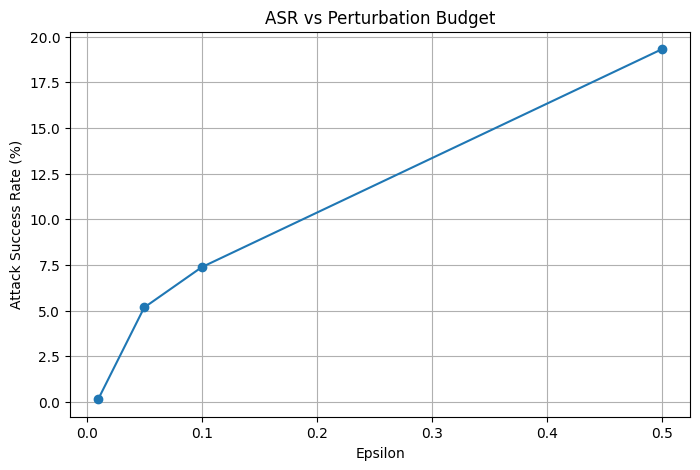

In [23]:
eps = [r["epsilon"] for r in results]
asr = [r["asr"] * 100 for r in results]

plt.figure(figsize=(8,5))
plt.plot(eps, asr, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
plt.title("ASR vs Perturbation Budget")
plt.grid(True)
plt.show()